<a href="https://colab.research.google.com/github/sayak395/Jaynes-Cummings-model/blob/main/Working_NEW_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qutip

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options, expect)
from scipy.signal import find_peaks

from scipy.interpolate import CubicSpline, PchipInterpolator
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.plots import plot_convergence
from skopt.utils import use_named_args

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.0 MB/s eta 0:00:00


In [3]:
# Hilbert space dimension for the cavity
n_cavity = 5
sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

wc = wa = 1.0  # Example values
g = 0.01 * wc

In [4]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 1), spin_down)
target_den = target_state * target_state.dag()

In [5]:

# === Define modulation function ===
def f_t(t, args):
    g_t = float(args['envelope'](t))
    return g_t

# === Time-dependent detunings ===
def delta_c_t(t, args):
    return wc - float(args['frequency'](t))

def delta_a_t(t, args):
    return wa - float(args['frequency'](t))

# === Define search space ===
space = [
    # FIXED (or ultra-narrow) envelope heights
    Real(-g, -0.5*g, name="Y1"),
    Real(0.98*g, g, name="Y2"),

    # Break-points ordered inside the pulse
    Real(0, 0.5, name="ΔX1"),
    Real(0.85, 1, name="ΔX2"),

    # Total simulation time
    Real(3/g, 4/g, name="SimTime"),

    # Chirp apex
    Real(wa, 1.1*wa, name="Freq1"),
    Real(0, 0.2*wa, name='Freq2'),

    # Apex location (fraction of τ)
    Real(0.45, 0.55, name="FX1")

]


# === Run optimization and analysis ===
def run_optimization_and_analysis(f_t, space, plot=True, n_calls=50, random_state=42):
    def objective_general(envelope_y1, envelope_y2, delta_ex1, delta_ex2, sim_time,
                          freq1, freq2, fx1):

        tau = wc * sim_time
        envelope_x1 = tau * min(delta_ex1, delta_ex2)
        envelope_x2 = tau * max(delta_ex1, delta_ex2)
        freq_x1 = tau * fx1

        if not (0 < envelope_x1 < envelope_x2 < tau):
            return 1.0
        if not (0 < freq_x1 < tau):
            return 1.0

        envelope_spline = CubicSpline([0, envelope_x1, envelope_x2, tau], [0, envelope_y1, envelope_y2, 0], extrapolate=False)
        frequency_spline = CubicSpline([0, freq_x1, tau], [wa , freq1, freq2])

        args = {'envelope': envelope_spline, 'frequency': frequency_spline}

        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]


        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e8, 'atol': 1e-7, 'rtol': 1e-7},
                             args=args)
            final_rho = result.states[-1]
            fidelity_custom = expect(target_state.proj(), final_rho)
            return -fidelity_custom
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res_1 = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, Y2, delta_X1, delta_X2, sim_time, freq1, freq2, fx1) = res_1.x
        tau = wc * sim_time
        X1 = tau * min(delta_X1, delta_X2)
        X2 = tau * max(delta_X1, delta_X2)
        freq_x1 = tau * fx1

        tau_arr = np.linspace(0, tau, 5000)
        envelope_spline = CubicSpline([0, X1, X2, tau], [0, Y1, Y2, 0], extrapolate=False)
        frequency_spline = CubicSpline([0, freq_x1, tau], [wa, freq1, freq2])
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)
        phase = np.cumsum(omega_t) * np.diff(tau_arr, prepend=0)



        # === Plot 1: Modulated wave and envelope ===
        plt.figure(figsize=(10, 6))
        #plt.plot(tau_arr, envelope * np.cos(omega_t * tau_arr), label=r'$g(t)\cos(\omega(t)t)$', linewidth=2)
        plt.plot(tau_arr, envelope * np.cos(phase),
         label=r'$\phi(t)$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Control Points')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 2: Convergence ===
        plt.figure(figsize=(10, 6))
        plot_convergence(res_1)
        plt.tight_layout()

        # === Plot 3: Objective landscape ===
        fig, ax = plt.subplots(figsize=(36, 34))
        ax = plot_objective(res_1, dimensions=[
            'Y1', 'Y2', 'ΔX1', 'ΔX2', 'SimTime',
            'Freq1', 'Freq2','FX1'
        ], n_points=20, levels=20)
        plt.tight_layout()

        # === Plot 4: Population dynamics ===
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        solver_opts = Options(
        nsteps=int(1e6),      # or whatever you need
        atol=1e-7,
        rtol=1e-7,
        store_states=True     # <─ this is where it lives now
        )

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args, options=solver_opts)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # === Plot 5: ω(t) ===
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.scatter([freq_x1], [freq1], color='black', marker='x', s=80, label='Frequency Control Point')
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 6: detuning ===
        omega_t = frequency_spline(tau_arr)
        delta_c = wc - omega_t
        delta_a = wa - omega_t

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, delta_c, label=r'$\Delta_c(t) = \omega_c - \omega(t)$', linewidth=2)
        plt.plot(tau_arr, delta_a, label=r'$\Delta_a(t) = \omega_a - \omega(t)$', linewidth=2)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.title('Time-Dependent Detunings')
        plt.xlabel('Time')
        plt.ylabel('Detuning')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # === Plot 7: Cavity Fock State Populations ===
        fock_populations = {n: [] for n in range(n_cavity)}
        for state in output.states:
            for n in range(n_cavity):
                projector = tensor(fock(n_cavity, n).proj(), qeye(2))
                fock_populations[n].append(expect(projector, state))

        plt.figure(figsize=(10, 6))
        for n in range(n_cavity):
            plt.plot(tau_arr, fock_populations[n], label=f'Fock |{n}⟩')
        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title("Cavity Fock State Populations Over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    return res_1

# Now call the function
res_1 = run_optimization_and_analysis(f_t, space)

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.2990
Function value obtained: -0.0065
Current minimum: -0.0065
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.2336
Function value obtained: -0.0078
Current minimum: -0.0078
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.6531
Function value obtained: -0.8704
Current minimum: -0.8704
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.2554
Function value obtained: -0.0675
Current minimum: -0.8704
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.2052
Function value obtained: -0.0097
Current minimum: -0.8704
Iteration No: 6 started. 

KeyboardInterrupt: 

In [24]:
param_names = ["Y1", "Y2", "ΔX1", "ΔX2", "SimTime", "Freq1", 'Freq2', "FX1"]
for name, val in zip(param_names, res_1.x):
    print(f"{name} = {val:.6f}")

Y1 = 0.000000
Y2 = 0.009899
ΔX1 = 0.802464
ΔX2 = 0.931063
SimTime = 400.000000
Freq1 = 1.006300
Freq2 = 0.024452
FX1 = 0.548579


trying something different

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.1886
Function value obtained: -0.2437
Current minimum: -0.2437
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.1615
Function value obtained: -0.2205
Current minimum: -0.2437
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.1485
Function value obtained: -0.5393
Current minimum: -0.5393
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.1719
Function value obtained: -0.1849
Current minimum: -0.5393
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.1250
Function value obtained: -0.1539
Current minimum: -0.5393
Iteration No: 6 started. 

/usr/local/lib/python3.11/dist-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


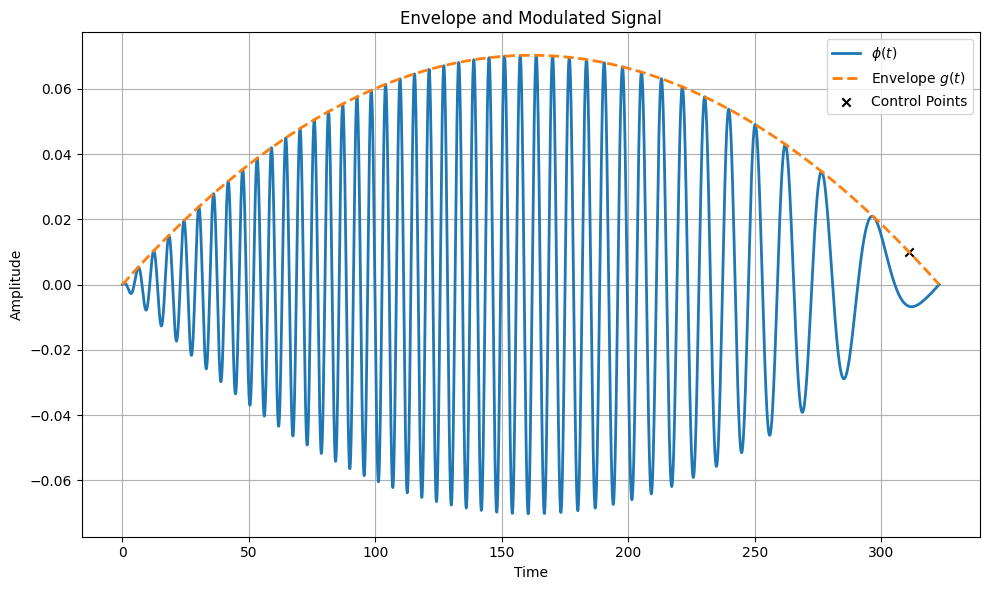

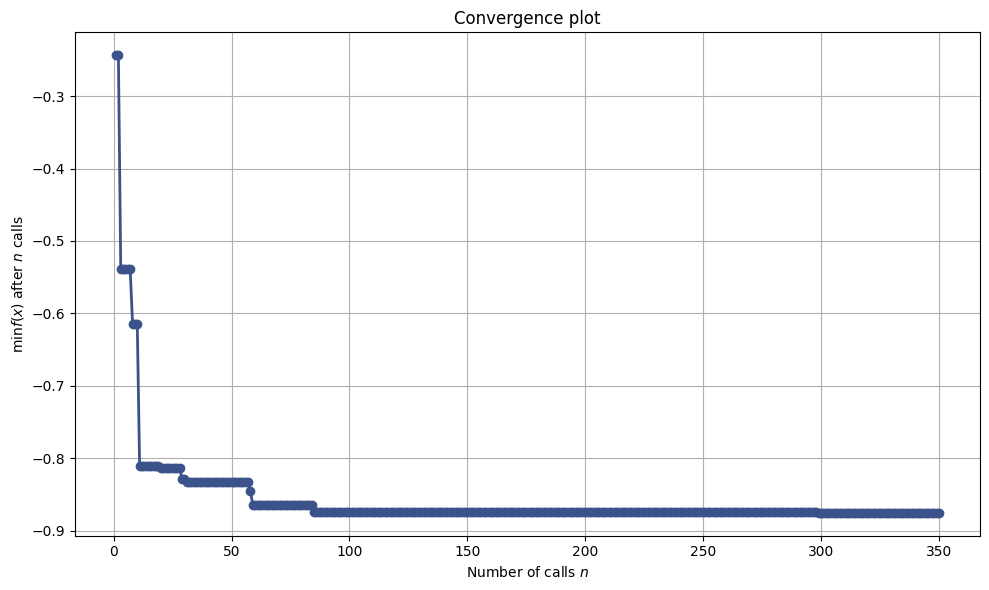

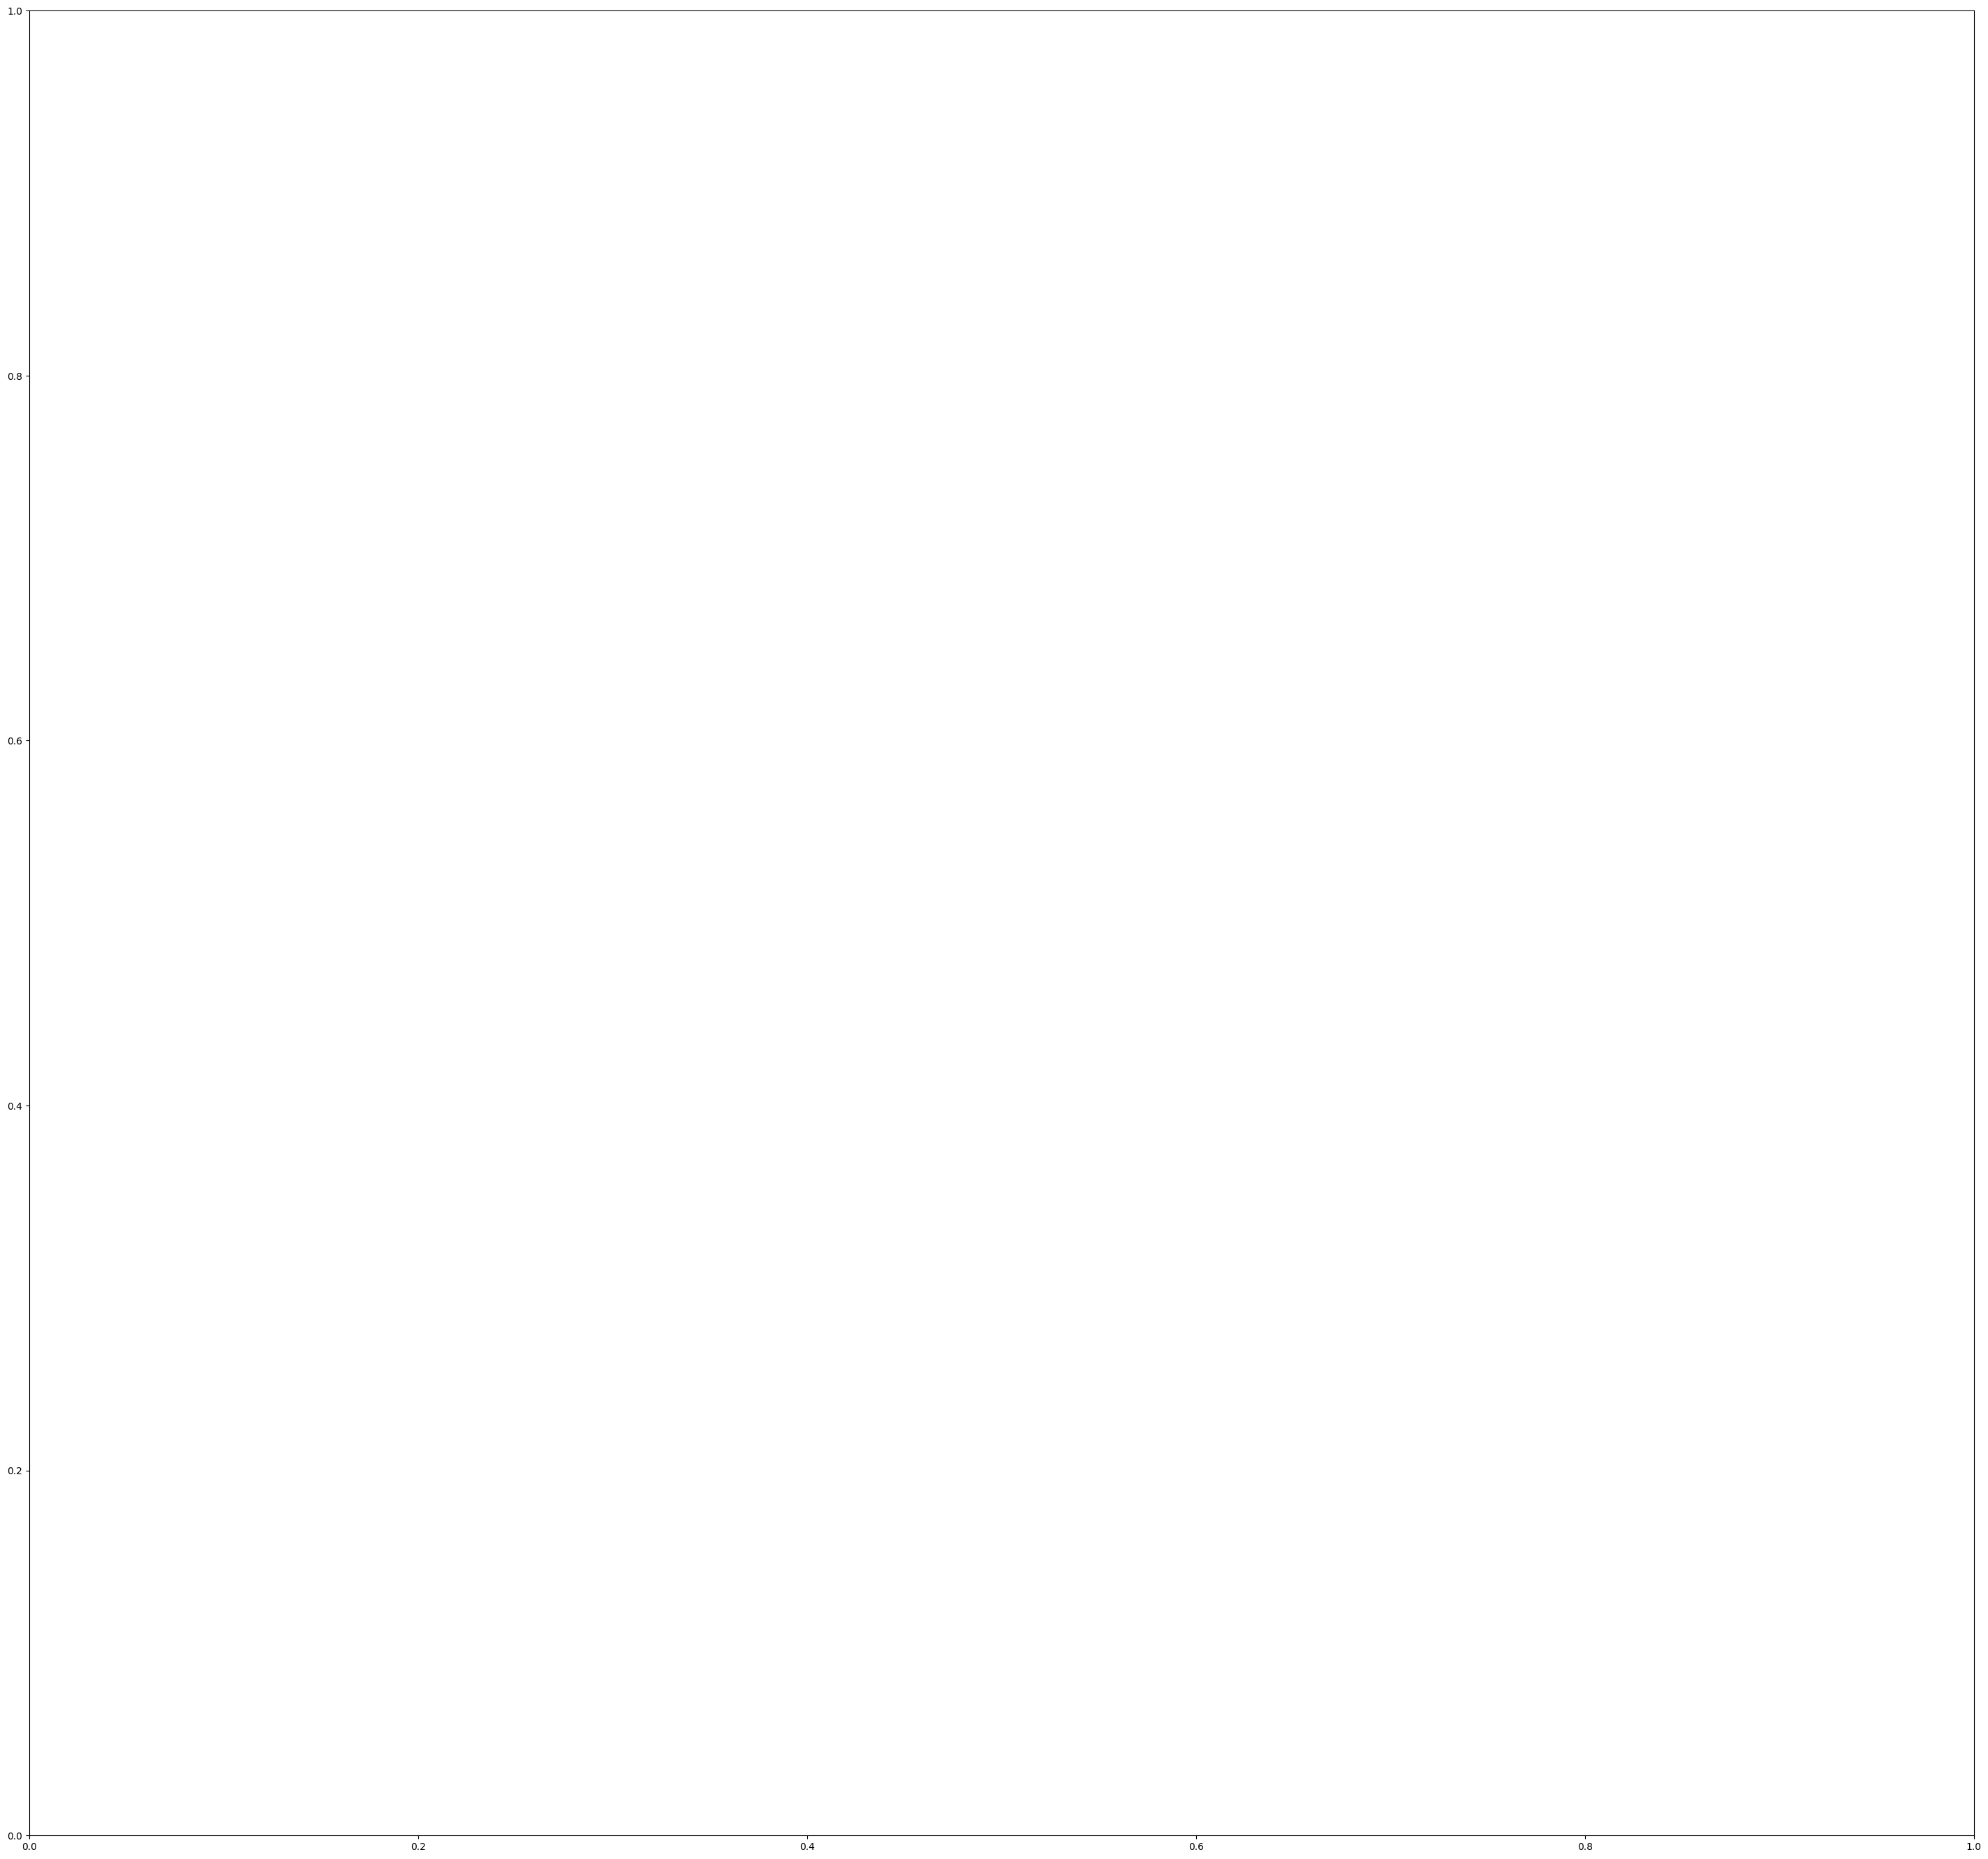

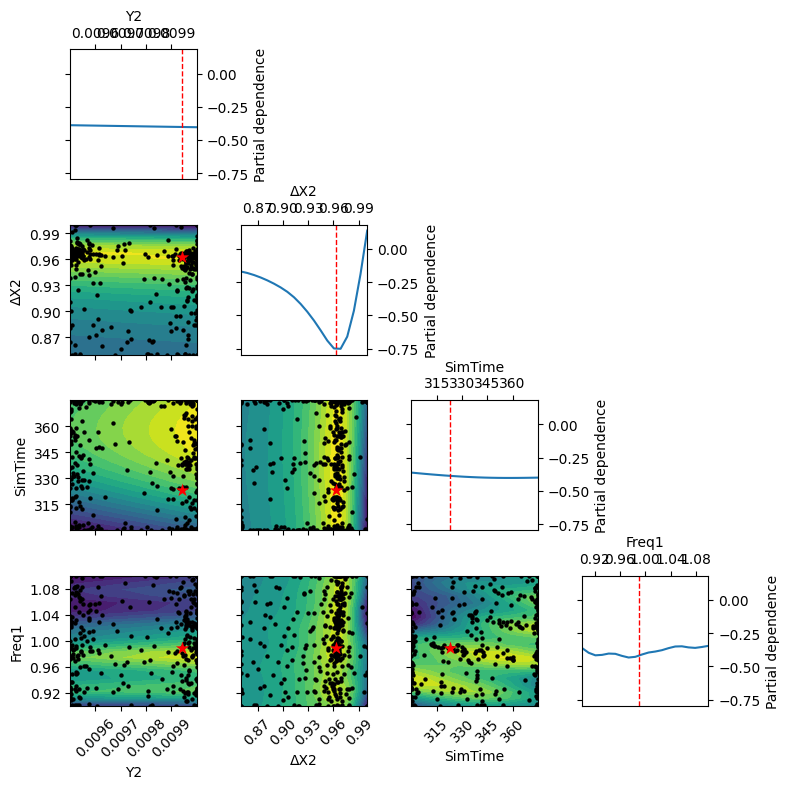

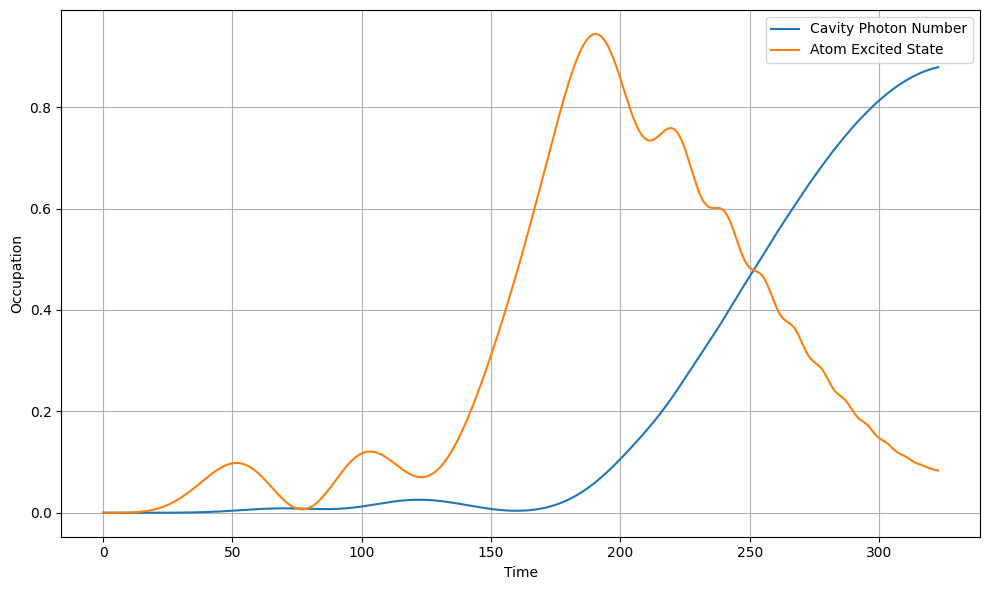

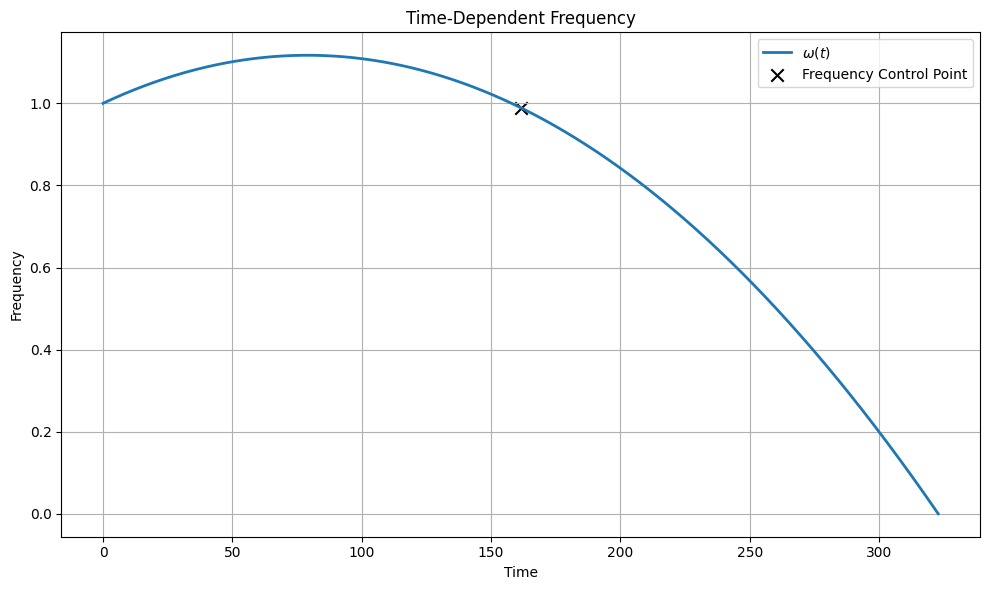

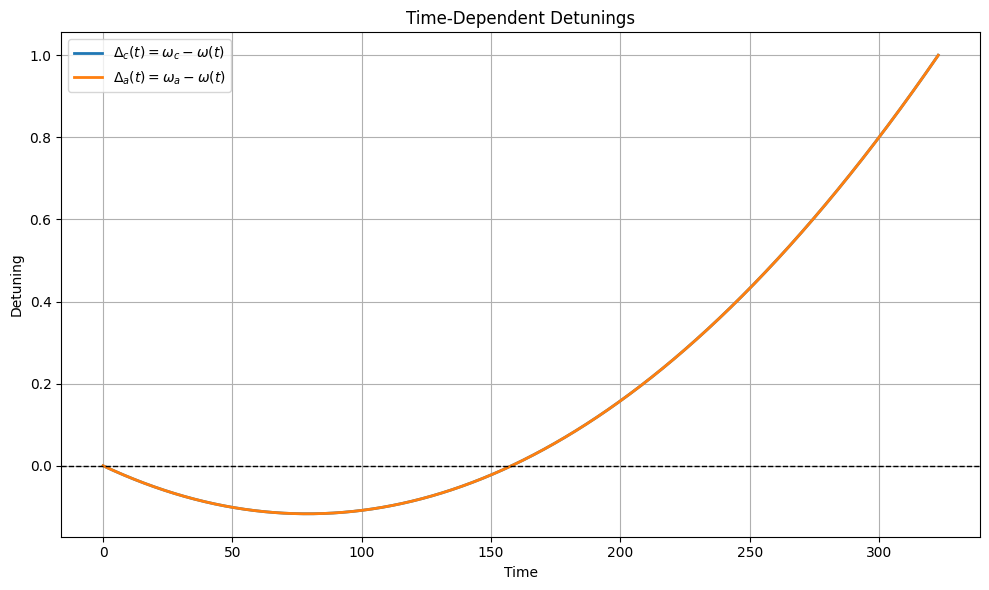

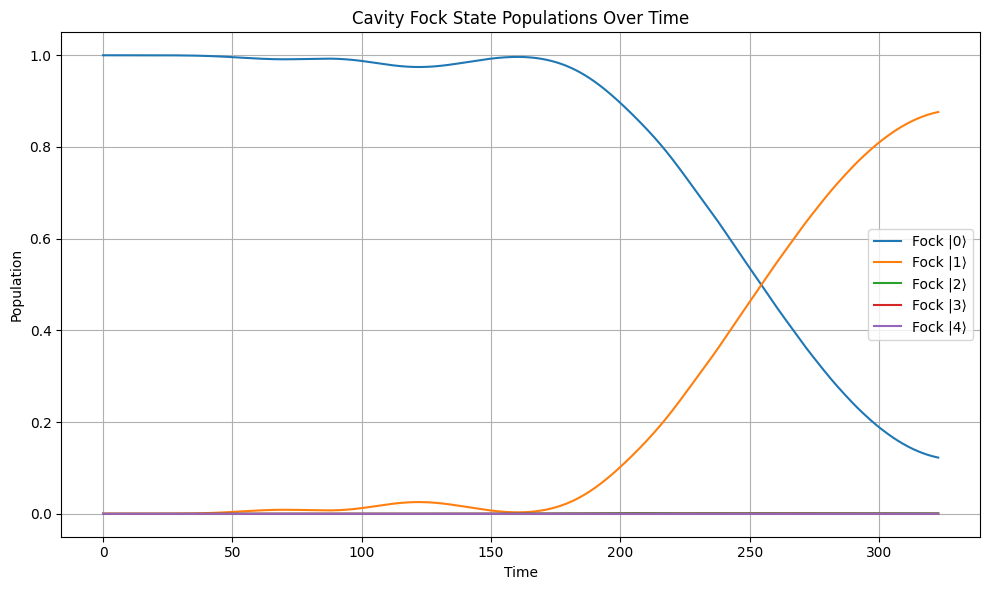

In [33]:

# === Define modulation function ===
def f_t(t, args):
    g_t = float(args['envelope'](t))
    return g_t

# === Time-dependent detunings ===
def delta_c_t(t, args):
    return wc - float(args['frequency'](t))

def delta_a_t(t, args):
    return wa - float(args['frequency'](t))

# === Define search space ===
space = [
    # FIXED (or ultra-narrow) envelope heights
    #Real(-g, -0.5*g, name="Y1"),
    Real(0.95*g, g, name="Y2"),

    # Break-points ordered inside the pulse
    #Real(0, 0.5, name="ΔX1"),
    Real(0.85, 1, name="ΔX2"),

    # Total simulation time
    Real(3/g, 3.75/g, name="SimTime"),

    # Chirp apex
    Real(0.9*wa, 1.1*wa, name="Freq1"),
    #Real(0, 0.2*wa, name='Freq2'),

    # Apex location (fraction of τ)
    #Real(0.45, 0.55, name="FX1")

]


# === Run optimization and analysis ===
def run_optimization_and_analysis(f_t, space, plot=True, n_calls=350, random_state=42):
    def objective_general(envelope_y2, delta_ex2, sim_time,
                          freq1):

        tau = wc * sim_time
        #envelope_x1 = tau * min(delta_ex1, delta_ex2)
        envelope_x2 = tau * delta_ex2

        if not (0 < envelope_x2 < tau):
            return 1.0

        envelope_spline = CubicSpline([0, envelope_x2, tau], [0, envelope_y2, 0], extrapolate=False)
        frequency_spline = CubicSpline([0, tau/2, tau], [wa , freq1, 0])

        args = {'envelope': envelope_spline, 'frequency': frequency_spline}

        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]


        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e8, 'atol': 1e-7, 'rtol': 1e-7},
                             args=args)
            final_rho = result.states[-1]
            fidelity_custom = expect(target_state.proj(), final_rho)
            return -fidelity_custom
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res_1 = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y2, delta_X2, sim_time, freq1) = res_1.x
        tau = wc * sim_time
        #X1 = tau * min(delta_X1, delta_X2)
        X2 = tau * delta_X2

        tau_arr = np.linspace(0, tau, 5000)
        envelope_spline = CubicSpline([0, X2, tau], [0, Y2, 0], extrapolate=False)
        frequency_spline = CubicSpline([0, tau/2, tau], [wa, freq1, 0])
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)
        phase = np.cumsum(omega_t) * np.diff(tau_arr, prepend=0)



        # === Plot 1: Modulated wave and envelope ===
        plt.figure(figsize=(10, 6))
        #plt.plot(tau_arr, envelope * np.cos(omega_t * tau_arr), label=r'$g(t)\cos(\omega(t)t)$', linewidth=2)
        plt.plot(tau_arr, envelope * np.cos(phase),
         label=r'$\phi(t)$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X2], [Y2], marker='x', color='black', label='Control Points')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 2: Convergence ===
        plt.figure(figsize=(10, 6))
        plot_convergence(res_1)
        plt.tight_layout()

        # === Plot 3: Objective landscape ===
        fig, ax = plt.subplots(figsize=(36, 34))
        ax = plot_objective(res_1, dimensions=[
            'Y2', 'ΔX2', 'SimTime',
            'Freq1'
        ], n_points=20, levels=20)
        plt.tight_layout()

        # === Plot 4: Population dynamics ===
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        solver_opts = Options(
        nsteps=int(1e6),      # or whatever you need
        atol=1e-7,
        rtol=1e-7,
        store_states=True     # <─ this is where it lives now
        )

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args, options=solver_opts)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # === Plot 5: ω(t) ===
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.scatter([tau/2], [freq1], color='black', marker='x', s=80, label='Frequency Control Point')
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 6: detuning ===
        omega_t = frequency_spline(tau_arr)
        delta_c = wc - omega_t
        delta_a = wa - omega_t

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, delta_c, label=r'$\Delta_c(t) = \omega_c - \omega(t)$', linewidth=2)
        plt.plot(tau_arr, delta_a, label=r'$\Delta_a(t) = \omega_a - \omega(t)$', linewidth=2)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.title('Time-Dependent Detunings')
        plt.xlabel('Time')
        plt.ylabel('Detuning')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # === Plot 7: Cavity Fock State Populations ===
        fock_populations = {n: [] for n in range(n_cavity)}
        for state in output.states:
            for n in range(n_cavity):
                projector = tensor(fock(n_cavity, n).proj(), qeye(2))
                fock_populations[n].append(expect(projector, state))

        plt.figure(figsize=(10, 6))
        for n in range(n_cavity):
            plt.plot(tau_arr, fock_populations[n], label=f'Fock |{n}⟩')
        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title("Cavity Fock State Populations Over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    return res_1

# Now call the function
res_1 = run_optimization_and_analysis(f_t, space)

In [34]:
param_names = ["Y2", "ΔX2", "SimTime", "Freq1", "Freq2", "FX1"]
for name, val in zip(param_names, res_1.x):
    print(f"{name} = {val:.6f}")

Y2 = 0.009942
ΔX2 = 0.963292
SimTime = 322.912144
Freq1 = 0.989348


attempt to go to 2 down

In [9]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 2), spin_down)
target_den = target_state * target_state.dag()

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0418
Function value obtained: -0.3006
Current minimum: -0.3006
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0887
Function value obtained: -0.0491
Current minimum: -0.3006
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0448
Function value obtained: -0.2096
Current minimum: -0.3006
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0485
Function value obtained: -0.0001
Current minimum: -0.3006
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.0385
Function value obtained: -0.0188
Current minimum: -0.3006
Iteration No: 6 started. 

/usr/local/lib/python3.11/dist-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


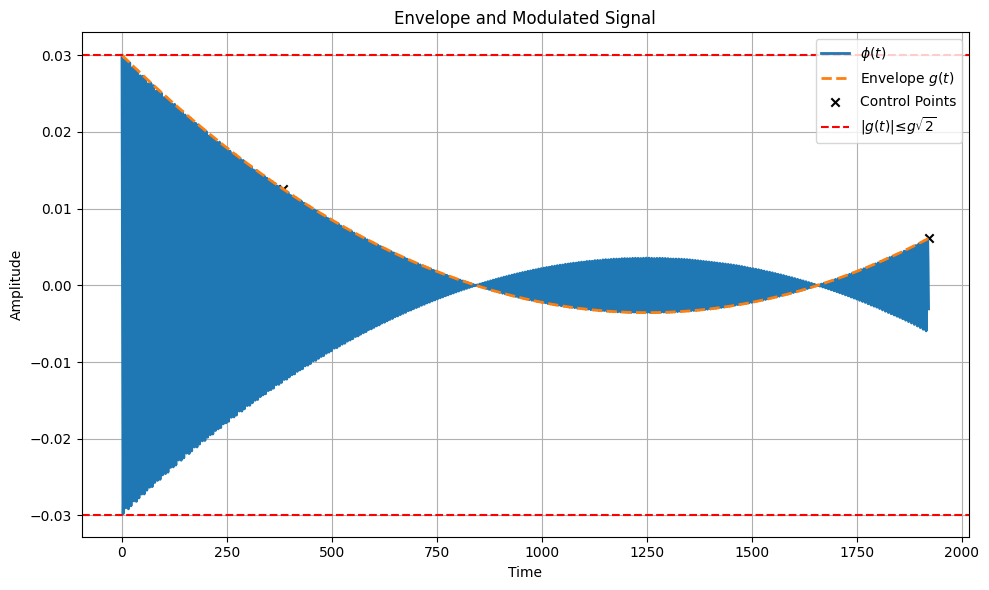

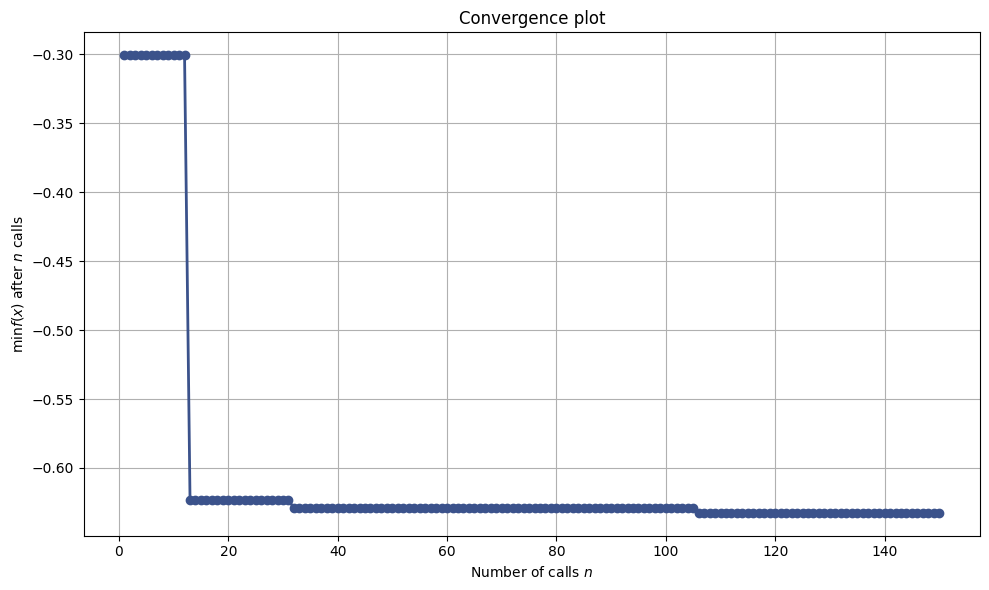

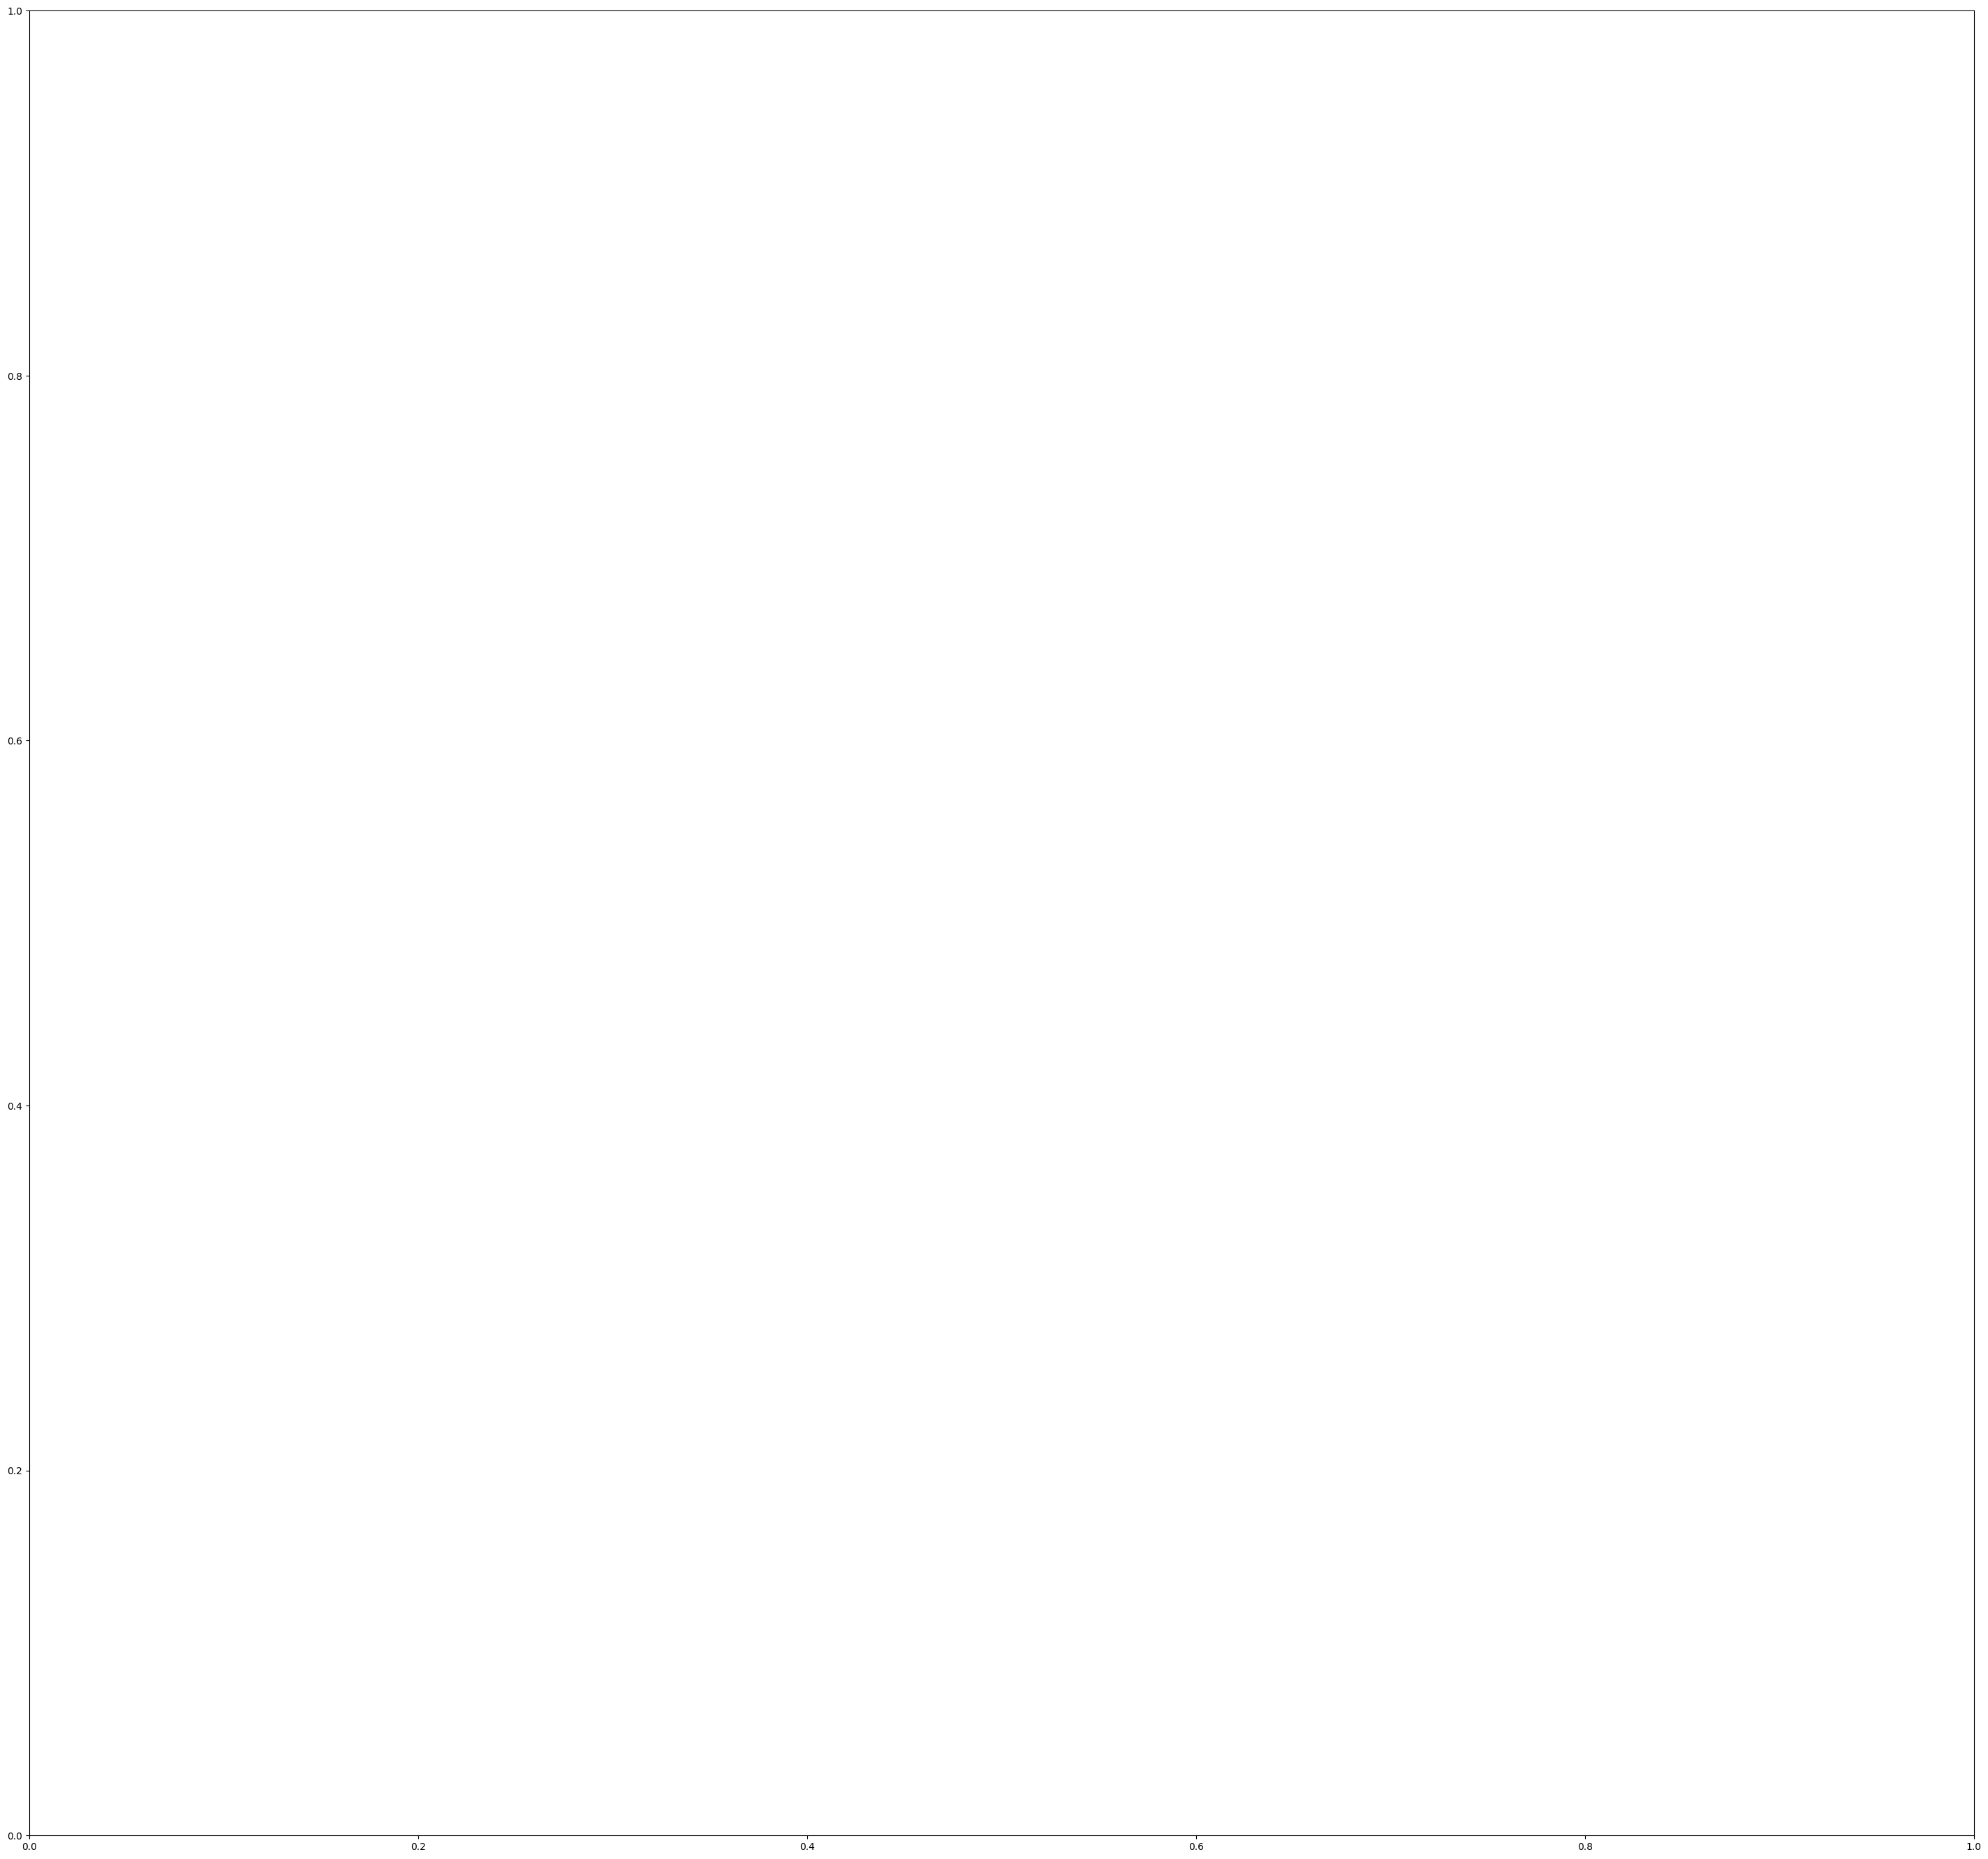

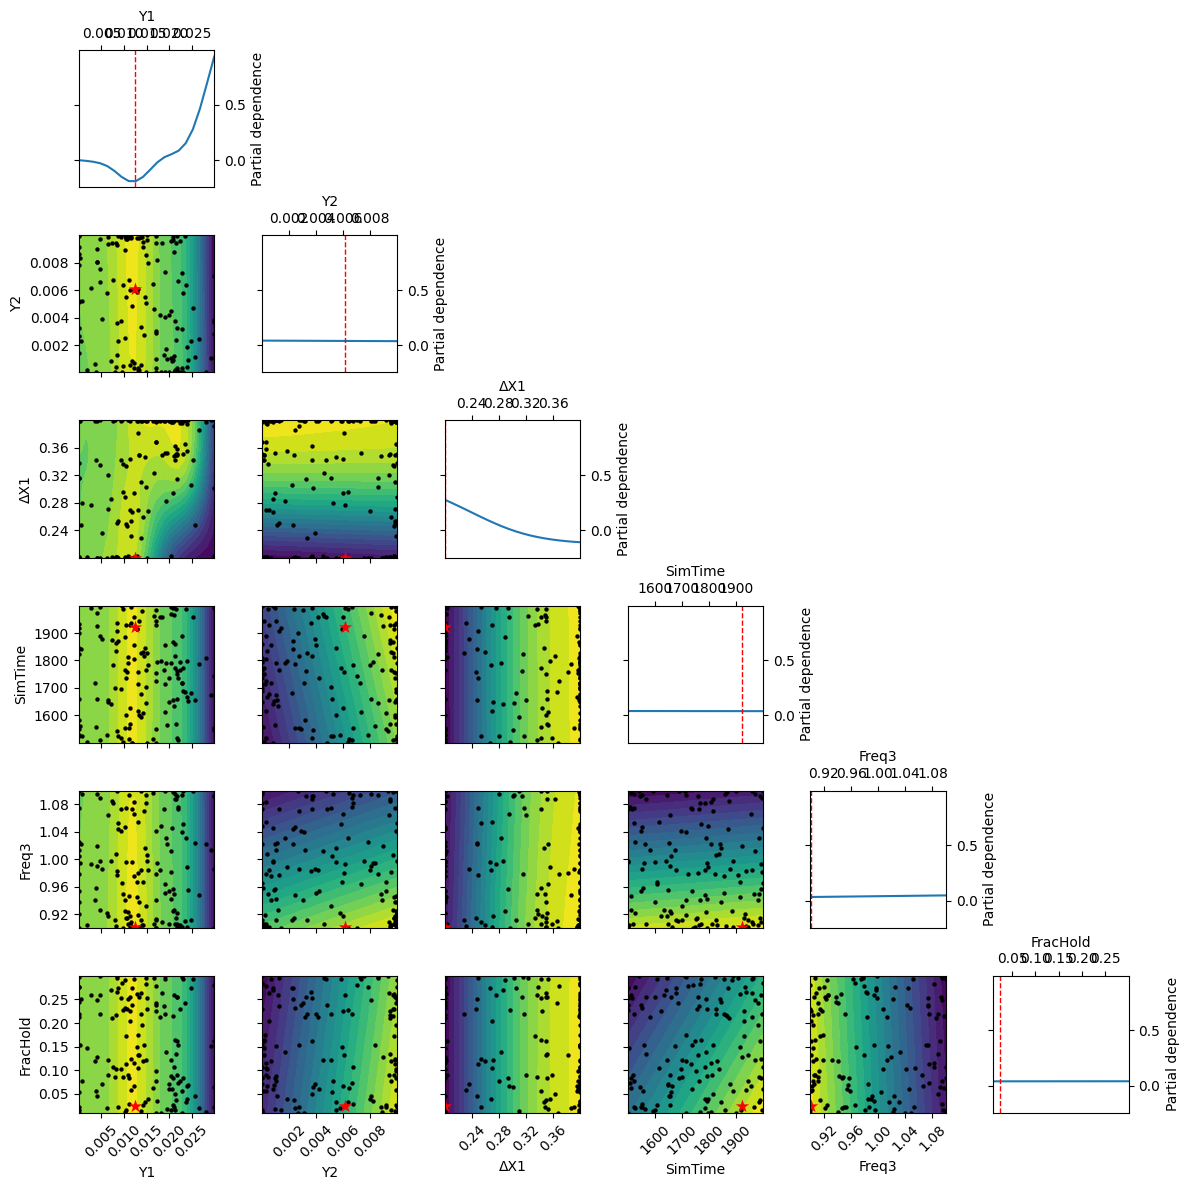

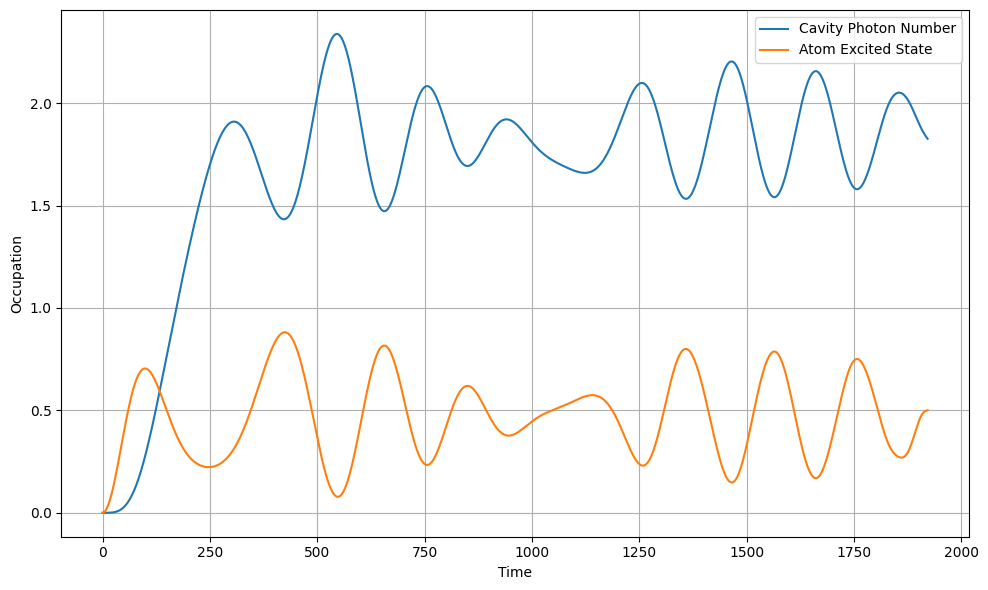

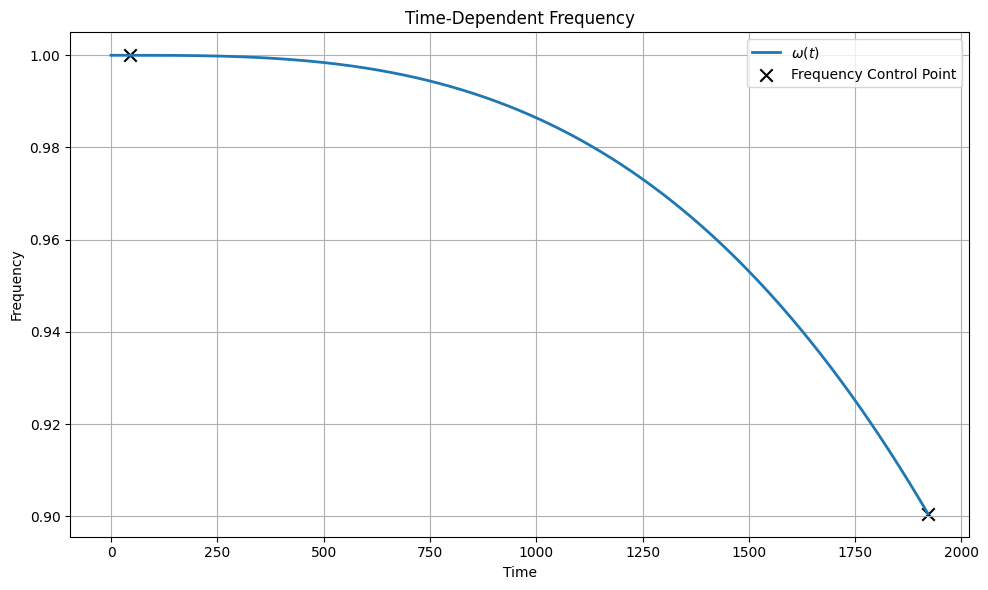

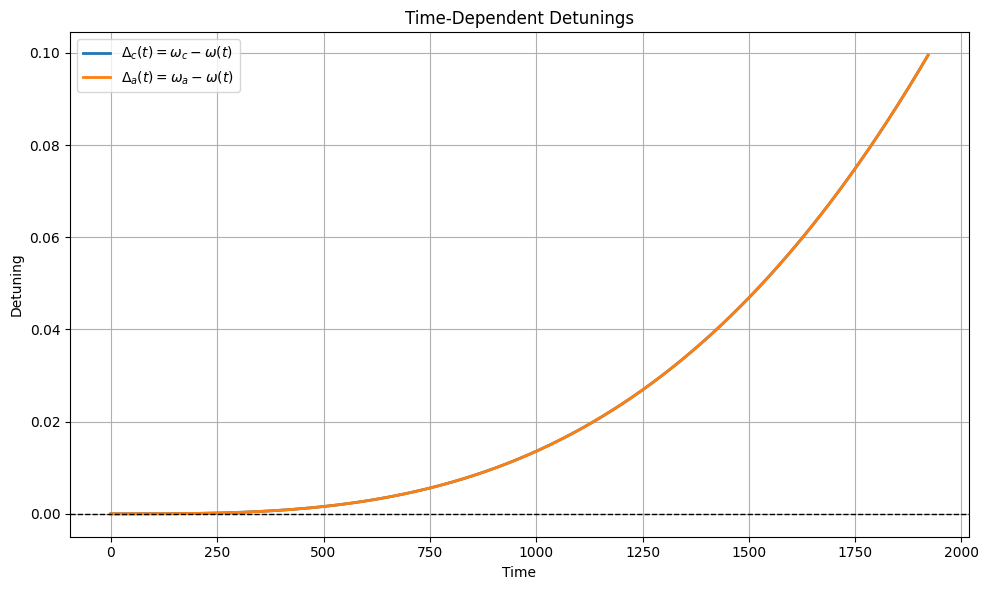

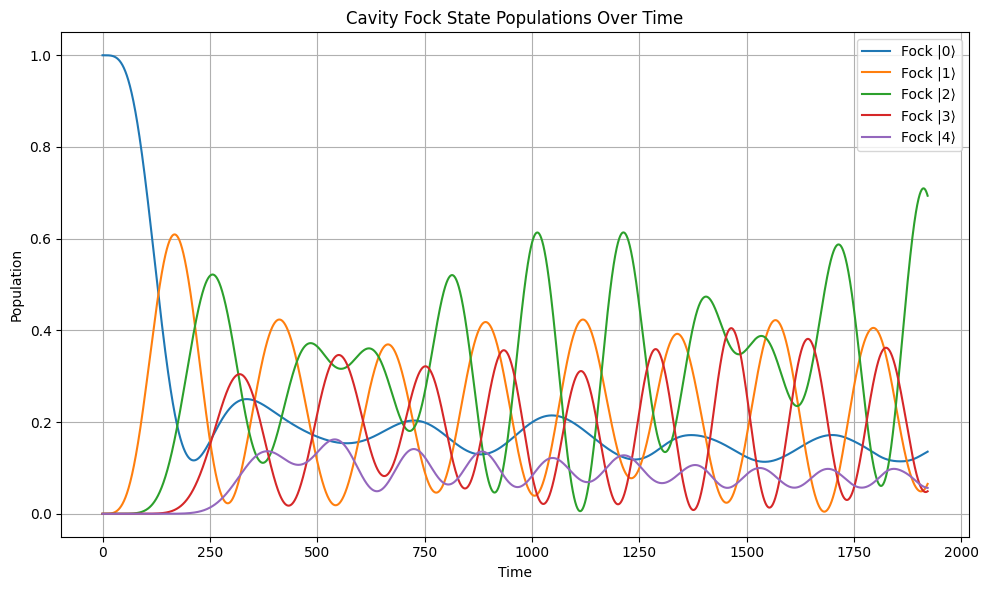

In [16]:
# === Define modulation function ===
def f_t(t, args):
    g_t = float(args['envelope'](t))
    return g_t

# === Time-dependent detunings ===
def delta_c_t(t, args):
    return wc - float(args['frequency'](t))

def delta_a_t(t, args):
    return wa - float(args['frequency'](t))

A_MAX = 3 * g

# === Define search space ===
space = [

    Real(0, A_MAX, name='Y1'),
    Real(0, g, name="Y2"),
    Real(0.2, 0.4, name='ΔX1'),   # 0.5 g → g√2
    Real(15/g, 20/g, name="SimTime"),
    Real(0.9*wa, 1.1*wa, name='Freq3'),
    Real(0.01, 0.3, name='FracHold'),
]





# === Run optimization and analysis ===
def run_optimization_and_analysis(f_t, space, plot=True, n_calls=150, random_state=42):
    def objective_general(envelope_y1, envelope_y2, delta_ex1, sim_time, freq3, FracHold):

        tau = wc * sim_time
        envelope_x1 = tau * delta_ex1
        t_h = tau * FracHold


        if not (0 < envelope_x1 < tau):
            return 1.0



        envelope_spline = CubicSpline([0, envelope_x1, tau], [0, envelope_y1, envelope_y2], extrapolate=False)
        frequency_spline = CubicSpline([0, 0.5*t_h, t_h, tau], [wa, wa, wa, freq3], extrapolate=False)

        # ----- NEW: amplitude ceiling check --------------------------
        if np.nanmax(np.abs(envelope_spline(np.linspace(0, tau, 50)))) > A_MAX:
            return 1.0

        args = {'envelope': envelope_spline, 'frequency': frequency_spline}

        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]


        try:
            result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                             options={'nsteps': 1e6, 'atol': 1e-5, 'rtol': 1e-5},
                             args=args)
            final_rho = result.states[-1]
            fidelity_custom = expect(target_state.proj(), final_rho)
            return -fidelity_custom
        except Exception as e:
            print("Simulation error:", e)
            return 1.0

    def objective(x):
        return objective_general(*x)

    res_2 = gp_minimize(objective, space, n_calls=n_calls, random_state=random_state, verbose=True, acq_func='EI')

    if plot:
        (Y1, Y2, delta_X1, sim_time, freq3, FracHold) = res_2.x
        tau = wc * sim_time
        X1 = tau * delta_X1
        t_h = tau * FracHold


        tau_arr = np.linspace(0, tau, 5000)
        envelope_spline = CubicSpline([0, X1, tau], [3*g, Y1, Y2], extrapolate=False)
        frequency_spline = CubicSpline([0, 0.5*t_h, t_h, tau], [wa, wa, wa, freq3], extrapolate=False)
        envelope = envelope_spline(tau_arr)
        omega_t = frequency_spline(tau_arr)
        phase = np.cumsum(omega_t) * np.diff(tau_arr, prepend=0)



        # === Plot 1: Modulated wave and envelope ===
        plt.figure(figsize=(10, 6))
        #plt.plot(tau_arr, envelope * np.cos(omega_t * tau_arr), label=r'$g(t)\cos(\omega(t)t)$', linewidth=2)
        plt.plot(tau_arr, envelope * np.cos(phase), label=r'$\phi(t)$', linewidth=2)
        plt.plot(tau_arr, envelope, label=r'Envelope $g(t)$', linestyle='--', linewidth=2)
        plt.scatter([X1, tau], [Y1, Y2], marker='x', color='black', label='Control Points')
        plt.axhline(A_MAX,  color='red', linestyle='--', label=r'$|g(t)| ≤ g \sqrt{2}$')
        plt.axhline(-A_MAX, color='red', linestyle='--')
        plt.title('Envelope and Modulated Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 2: Convergence ===
        plt.figure(figsize=(10, 6))
        plot_convergence(res_2)
        plt.tight_layout()

        # === Plot 3: Objective landscape ===
        fig, ax = plt.subplots(figsize=(36, 34))
        ax = plot_objective(res_2, dimensions=[
            'Y1', 'Y2', 'ΔX1', 'SimTime',
             'Freq3', 'FracHold'
        ], n_points=20, levels=20)
        plt.tight_layout()

        # === Plot 4: Population dynamics ===
        args = {'envelope': envelope_spline, 'frequency': frequency_spline}
        H_static = g * (a.dag() * sigma_minus + a * sigma_plus)

        solver_opts = Options(
        nsteps=int(1e7),      # or whatever you need
        atol=1e-7,
        rtol=1e-7,
        store_states=True     # <─ this is where it lives now
        )

        H = [
            H_static,
            [a.dag() * a, lambda t, args: delta_c_t(t, args)],
            [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
            [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
        ]
        output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args, options=solver_opts)
        n_c = output.expect[0]
        n_a = output.expect[1]

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, n_c, label='Cavity Photon Number')
        plt.plot(tau_arr, n_a, label='Atom Excited State')
        plt.xlabel('Time')
        plt.ylabel('Occupation')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # === Plot 5: ω(t) ===
        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
        plt.scatter([t_h, tau], [wa, freq3], color='black', marker='x', s=80, label='Frequency Control Point')
        plt.title('Time-Dependent Frequency')
        plt.xlabel('Time')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        # === Plot 6: detuning ===
        omega_t = frequency_spline(tau_arr)
        delta_c = wc - omega_t
        delta_a = wa - omega_t

        plt.figure(figsize=(10, 6))
        plt.plot(tau_arr, delta_c, label=r'$\Delta_c(t) = \omega_c - \omega(t)$', linewidth=2)
        plt.plot(tau_arr, delta_a, label=r'$\Delta_a(t) = \omega_a - \omega(t)$', linewidth=2)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.title('Time-Dependent Detunings')
        plt.xlabel('Time')
        plt.ylabel('Detuning')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # === Plot 7: Cavity Fock State Populations ===
        fock_populations = {n: [] for n in range(n_cavity)}
        for state in output.states:
            for n in range(n_cavity):
                projector = tensor(fock(n_cavity, n).proj(), qeye(2))
                fock_populations[n].append(expect(projector, state))

        plt.figure(figsize=(10, 6))
        for n in range(n_cavity):
            plt.plot(tau_arr, fock_populations[n], label=f'Fock |{n}⟩')
        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title("Cavity Fock State Populations Over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    return res_2

# Now call the function
res_2 = run_optimization_and_analysis(f_t, space)

In [15]:
param_names = ['Y1', "Y2", "ΔX1", "SimTime",'Freq3', 'Frach_Hold']
for name, val in zip(param_names, res_2.x):
    print(f"{name} = {val:.6f}")

Y1 = 0.016637
Y2 = 0.006585
ΔX1 = 0.314773
SimTime = 1455.031877
Freq3 = 1.094985
Frach_Hold = 0.028828
